## 01 - Análisis Exploratorio de Datos (EDA) y Calidad de Datos

- Objetivo de esta sección:

 Realizar la ingesta del dataset preprocesado por el equipo, validar su estructura física y asegurar la consistencia técnica de las variables antes del análisis estadístico.

## 1. Configuración del Entorno
En esta celda se importan las librerías esenciales para la manipulación de datos, análisis matemático y visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración para que los gráficos se vean integrados y limpios
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Ingesta de Datos
Cargamos el dataset limpio generado en la etapa anterior (`dataset_clean.csv`) ubicado en la carpeta compartida de datos. Se realiza una verificación inicial de las primeras filas.

In [2]:
# Definimos la ruta relativa hacia la carpeta data
data_path = '../data/dataset_clean.csv'

# Validamos si el archivo realmente existe antes de cargarlo para evitar errores
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"¡Éxito! Dataset cargado correctamente. Total de registros: {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print("Error: No se encontró el archivo 'dataset_clean.csv' en la ruta especificada.")

# Visualización de muestra
df.head()

¡Éxito! Dataset cargado correctamente. Total de registros: 1186 filas y 8 columnas.


,Country,City,Industry,join_year,join_month,years_since_joined,investors_count,valuation_b
0,China,Beijing,Artificial intelligence,2017,4,9.20,4,140.0
1,United States,Hawthorne,Other,2012,12,13.54,3,127.0
2,China,Shenzhen,E-commerce & direct-to-consumer,2018,7,7.96,3,100.0
3,United States,San Francisco,Fintech,2014,1,12.40,3,95.0
4,Australia,Surry Hills,Internet software & services,2018,1,8.44,3,40.0


## 3. Validación Estructurada del Dataset
Para cerrar este issue, realizamos una auditoría de la estructura técnica del DataFrame:
1. Tipos de datos asignados a cada columna.
2. Confirmación de la ausencia de valores nulos (verificación del trabajo de limpieza).
3. Memoria consumida por el objeto.

In [3]:
# Inspección de tipos y nulos estructurada
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             1186 non-null   str    
 1   City                1186 non-null   str    
 2   Industry            1186 non-null   str    
 3   join_year           1186 non-null   int64  
 4   join_month          1186 non-null   int64  
 5   years_since_joined  1186 non-null   float64
 6   investors_count     1186 non-null   int64  
 7   valuation_b         1186 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 74.3 KB


In [4]:
# Doble verificación cuantitativa de nulos por columna
null_counts = df.isnull().sum()
print("Conteo de valores nulos por columna:")
print(null_counts[null_counts > 0] if any(null_counts > 0) else "¡Confirmado! 0% de valores nulos en todo el dataset.")

Conteo de valores nulos por columna:
¡Confirmado! 0% de valores nulos en todo el dataset.


## 4. Control de Registros Duplicados
Verificamos si existen filas idénticas duplicadas en el dataset para evitar sesgos en el análisis estadístico y en las futuras visualizaciones.

In [5]:
# Contar cuántas filas están duplicadas exactamente
total_duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados exactos: {total_duplicados}")

if total_duplicados == 0:
    print("¡Confirmado! No hay filas duplicadas. El dataset mantiene su integridad.")
else:
    print(f"Atención: Se encontraron {total_duplicados} filas duplicadas que requieren tratamiento.")

Cantidad de registros duplicados exactos: 0
¡Confirmado! No hay filas duplicadas. El dataset mantiene su integridad.


## 5. Análisis Univariante del Target (`valuation_b`) y Outliers
Visualizamos la distribución de la variable objetivo mediante un histograma (para ver su forma y concentración) y un diagrama de caja o Boxplot (para identificar formalmente los valores atípicos u outliers).

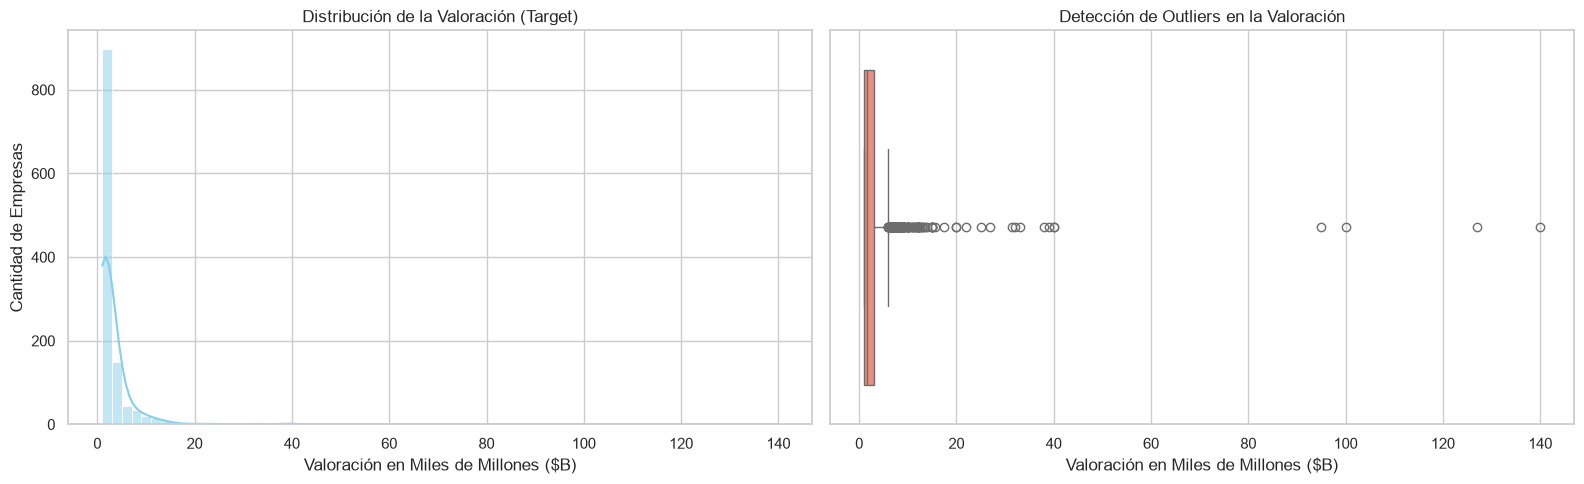

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma de Distribución
sns.histplot(df['valuation_b'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de la Valoración (Target)')
axes[0].set_xlabel('Valoración en Miles de Millones ($B)')
axes[0].set_ylabel('Cantidad de Empresas')

# 2. Boxplot para detectar Outliers
sns.boxplot(x=df['valuation_b'], color='salmon', ax=axes[1])
axes[1].set_title('Detección de Outliers en la Valoración')
axes[1].set_xlabel('Valoración en Miles de Millones ($B)')

plt.tight_layout()
plt.show()

### 📌 Conclusiones del Análisis del Target y Outliers (Revisión Visual):
1. **Distribución Concentrada:** Más del 85% del dataset (casi 900 startups) se concentra en el rango mínimo de valoración (1 a 2 billones de dólares), generando un sesgo a la derecha extremo.
2. **Outliers de Escala Global:** El Boxplot revela anomalías estadísticas masivas. Mientras que el comportamiento "normal" no supera los 10 billones, identificamos super-unicornios atípicos que alcanzan valoraciones extremas de **95, 100, 128 y hasta 140 billones de dólares**.

## 6. Análisis Multivariante: Valoración por País e Industria
Para entender dónde se concentra el valor de los unicornios a nivel global, agrupamos y sumamos la valoración (`valuation_b`) según el país de origen de la startup y el sector industrial al que pertenece. Mostramos el Top 10 en ambos casos para mantener la legibilidad.

C:\Users\camil\AppData\Local\Temp\ipykernel_53768\3314633344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis', ax=axes[0])
C:\Users\camil\AppData\Local\Temp\ipykernel_53768\3314633344.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='magma', ax=axes[1])


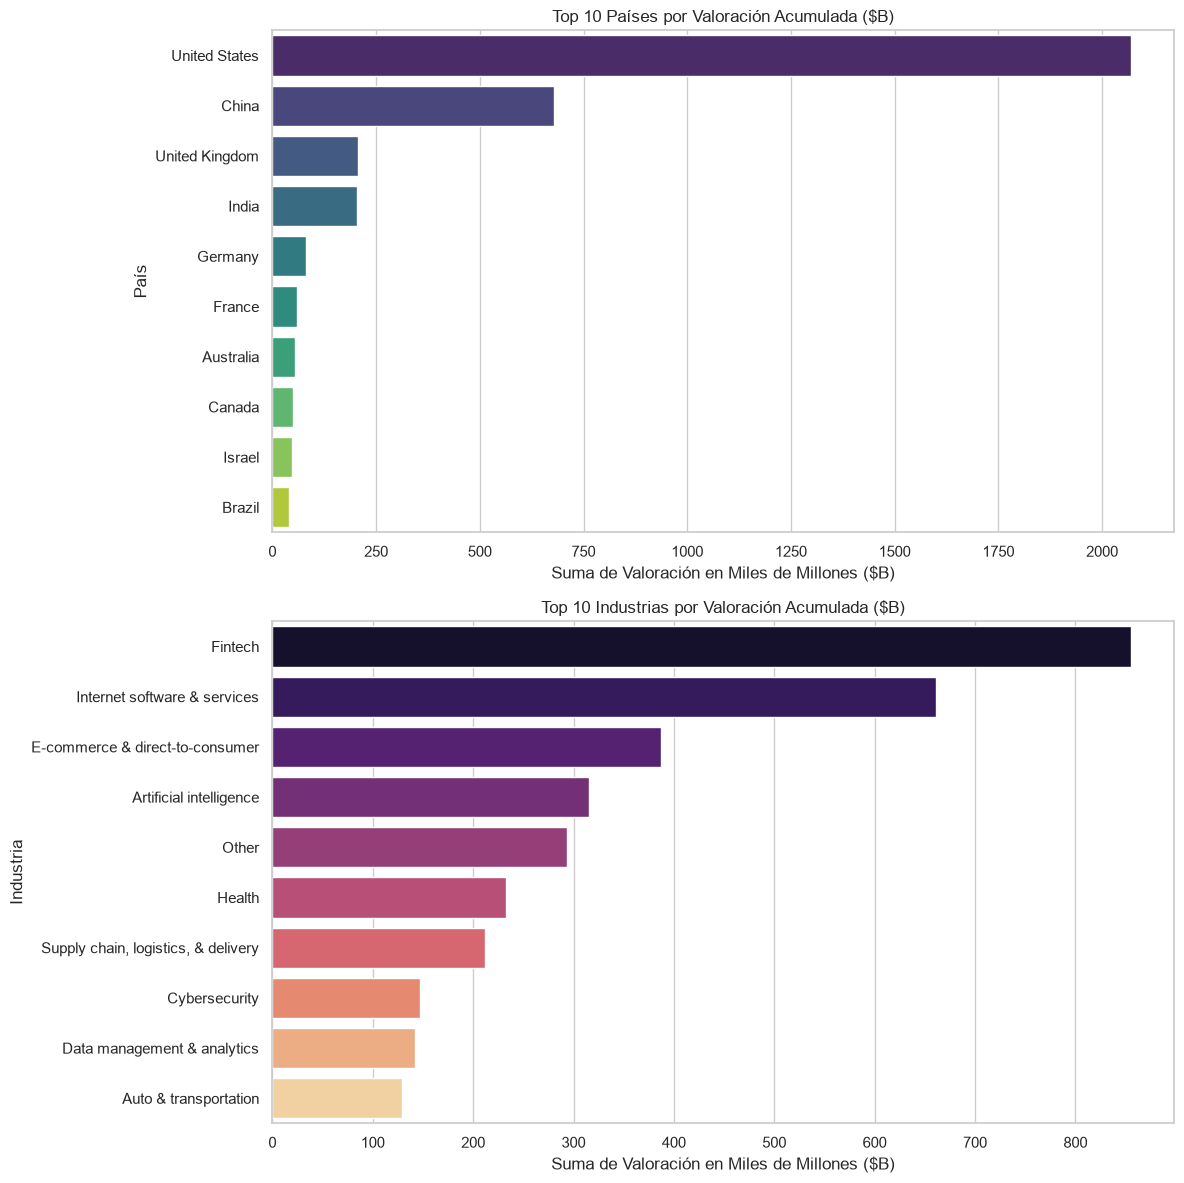

In [7]:
# Crear una figura con 2 subgráficos (uno arriba y otro abajo)
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Valoración acumulada por País (Top 10)
top_countries = df.groupby('Country')['valuation_b'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Países por Valoración Acumulada ($B)')
axes[0].set_xlabel('Suma de Valoración en Miles de Millones ($B)')
axes[0].set_ylabel('País')

# 2. Valoración por Industria (Top 10)
top_industries = df.groupby('Industry')['valuation_b'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Industrias por Valoración Acumulada ($B)')
axes[1].set_xlabel('Suma de Valoración en Miles de Millones ($B)')
axes[1].set_ylabel('Industria')

plt.tight_layout()
plt.show()

## 7. Análisis Temporal: Evolución de Creación de Unicornios
Analizamos la cantidad de startups que alcanzaron el estatus de unicornio a lo largo de los años. Esto nos permite identificar tendencias históricas y detectar si hubo periodos de "burbuja" o auge de inversión en el ecosistema tecnológico.

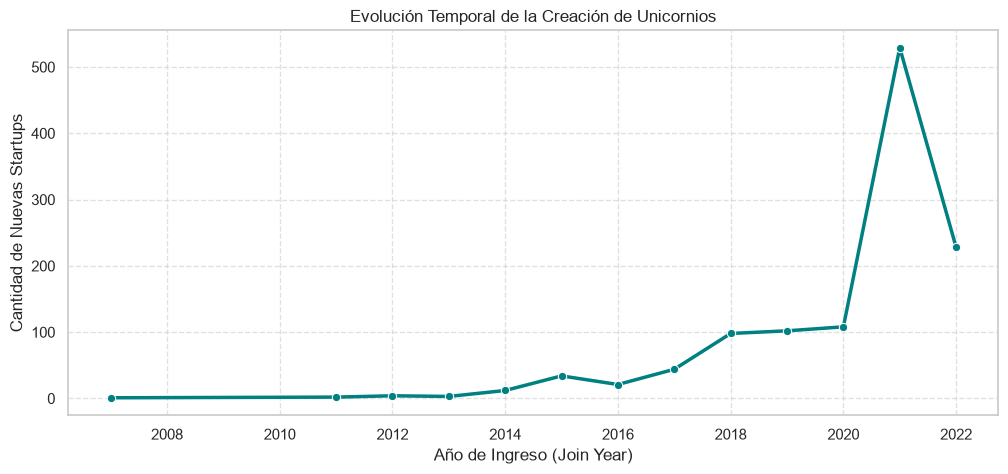

In [11]:
plt.figure(figsize=(12, 5))

# Corregido: Agrupar por 'join_year' en lugar de 'Year'
startups_year = df.groupby('join_year').size()

# Graficar la línea de tendencia temporal
sns.lineplot(x=startups_year.index, y=startups_year.values, marker='o', color='teal', linewidth=2.5)
plt.title('Evolución Temporal de la Creación de Unicornios')
plt.xlabel('Año de Ingreso (Join Year)')
plt.ylabel('Cantidad de Nuevas Startups')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Conclusiones del Análisis Temporal (`join_year`):
1. **El Boom del 2021:** Se observa un pico histórico masivo en el año 2021, donde la creación e ingreso de nuevos unicornios superó las 500 empresas en un solo año. Esto se debió a la alta liquidez del mercado financiero global y tasas de interés cercanas a cero durante la pandemia.
2. **Corrección de Mercado (2022):** A partir de 2022 se detecta una caída pronunciada (un descenso a casi la mitad del año anterior). Esto representa una estabilización o "vuelta a la realidad" del mercado, donde los inversores se volvieron mucho más estrictos con las valoraciones.
3. **Tendencia Histórica:** Antes de 2018, el ritmo de creación era prácticamente plano (menos de 50 por año), lo que demuestra que el fenómeno "unicornio" es extremadamente moderno y acelerado.